In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import sys
from pathlib import Path
from matplotlib import pyplot as plt

from lmfit.model import load_modelresult


In [2]:
# For manual stuff (added manually)

sys.path.append(r"C:\Users\ZAINTEL2\Dropbox\GitHub\VIENTO\LVM_helix\py_modules")
sys.path.append(r"C:\Users\ZAINTEL2\Dropbox\GitHub\VIENTO\LVM_helix")

from pipeline_config import MAPS_DIR, FIGS_DIR 
import results_comp
import ci_results_compiler
import plot_fit_params


In [3]:
H_file_name = "LVM-N7293-H"
O_file_name = "LVM-N7293-O"
N_file_name = "LVM-N7293-N"
#S_file_name = "MUSE-N346-S-bin2"

labels = ['H', 'O', 'N']

In [4]:
H_ = results_comp.load_line_bundle(H_file_name, "H_line", MAPS_DIR, read_header=True)
O_ = results_comp.load_line_bundle(O_file_name, "O_line", MAPS_DIR, read_header=True)
N_ = results_comp.load_line_bundle(N_file_name, "N_line", MAPS_DIR, read_header=True)


print(H_['obs']['V_mean'].var())
print(O_['obs']['V_mean'].var())
print(N_['obs']['V_mean'].var())


165.60699531908267
211.01508297447793
294.6148383350903


In [5]:
obs = [H_['obs']['V_mean'].var(), O_['obs']['V_mean'].var(), N_['obs']['V_mean'].var()]
obs

[165.60699531908267, 211.01508297447793, 294.6148383350903]

In [6]:
# H
name = H_file_name
result = load_modelresult("results_fit/" + name +"result_ideal.sav")
result_emcee = load_modelresult("results_fit/" + name +"result_emcee_ideal.sav")

fit_Br = {
    'result' : result,
    'result_emcee' : result_emcee }

H_line = ci_results_compiler.ci_results_compiler(fit_Br)

In [7]:
# 0
name = O_file_name
result = load_modelresult("results_fit/" + name +"result_ideal.sav")
result_emcee = load_modelresult("results_fit/" + name +"result_emcee_ideal.sav")

fit_Br = {
    'result' : result,
    'result_emcee' : result_emcee }

O_line = ci_results_compiler.ci_results_compiler(fit_Br)

In [8]:
# N
name = N_file_name
result = load_modelresult("results_fit/" + name +"result_ideal.sav")
result_emcee = load_modelresult("results_fit/" + name +"result_emcee_ideal.sav")

fit_Br = {
    'result' : result,
    'result_emcee' : result_emcee }

N_line = ci_results_compiler.ci_results_compiler(fit_Br)

In [9]:
H_line

{'sig2': [135.62228684401907, 29.380667646205893, 16.042211429794065],
 'r0': [0.27026039282951697, 0.064941140600483, 0.028640396462016965],
 'm': [1.2847296390813072, 0.15044772156619257, 0.13552843748630727],
 's0': [9.793255313992423e-05, 0.0013363924618600756, -3.601888436007578e-05],
 'noise': [5.507434230623339, 6.830010822764159, 5.124530726495839]}

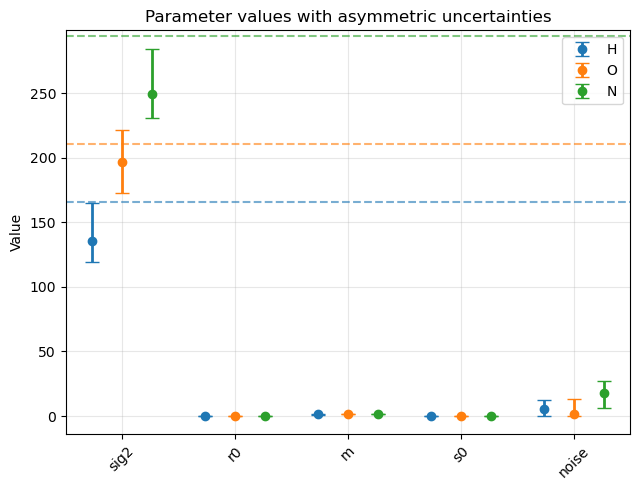

In [10]:

plot_fit_params.plot_param_comp_obs(H_line, O_line, N_line, labels=labels, obs=obs)

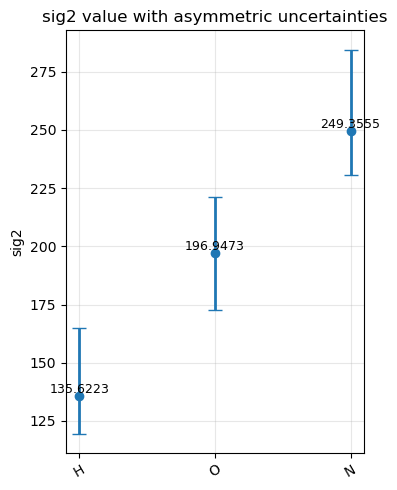

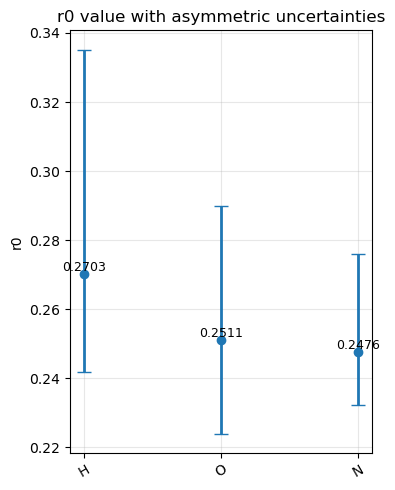

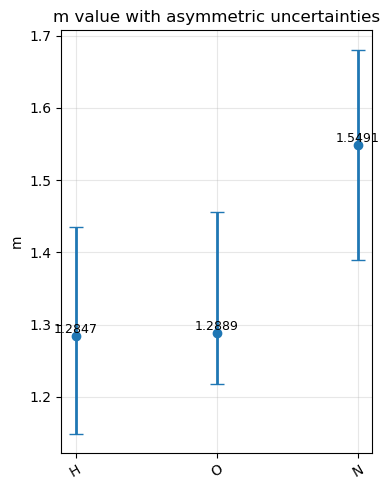

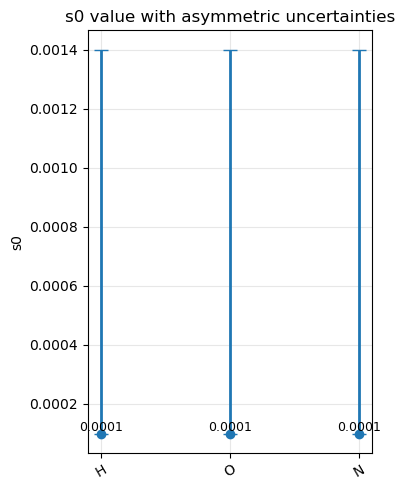

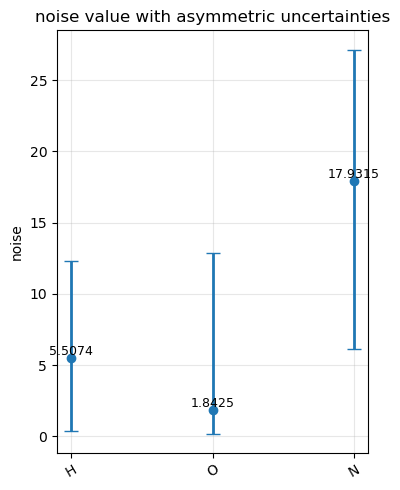

In [11]:
plot_fit_params.plot_param(H_line, O_line, N_line, labels=labels,
                                decimals=4)
